# Lasso Regression
> With Hyperparameter Tuning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso

In [3]:
df = pd.read_csv('Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
# features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

# split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

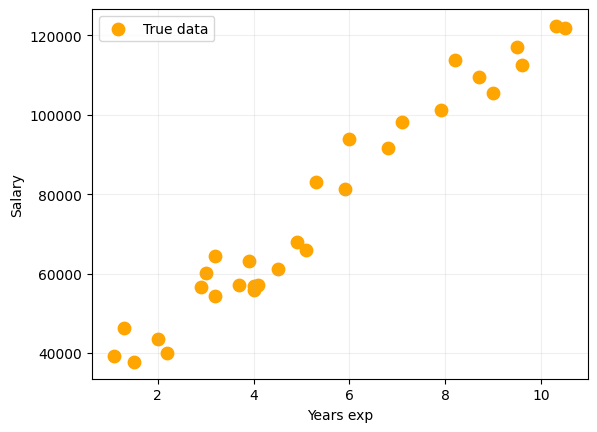

In [10]:
# data points
plt.scatter(x,y, color = 'Orange', s = 80, label = 'True data')
plt.xlabel('Years exp')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha = 0.2)
plt.show()


In [13]:
# Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)

y_Pred = lr.predict(x_test)
print('Intercept : ',lr.intercept_)
print('coef : ',lr.coef_)
print('R2 score: ',r2_score(y_test, y_Pred))

Intercept :  25321.583011776813
coef :  [9423.81532303]
R2 score:  0.9024461774180497


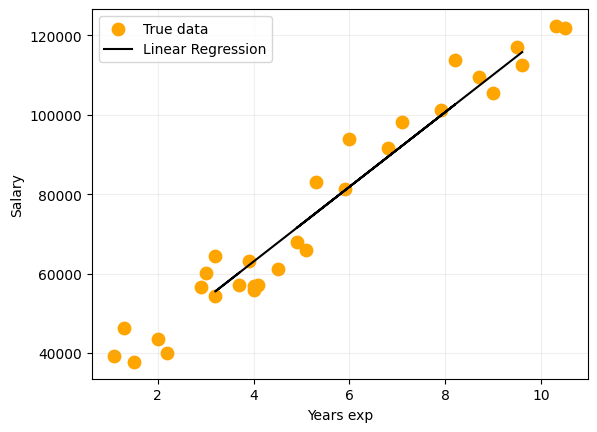

In [14]:
# line of Regression
plt.scatter(x,y, color = 'Orange', s = 80, label = 'True data')
plt.plot(x_test, y_Pred, color = 'k', label = 'Linear Regression')
plt.xlabel('Years exp')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha = 0.2)
plt.show()

## Lasso Regression

In [17]:
# hyperparameter tuning
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [1000, 5000, 10000],
    'tol': [1e-4, 1e-3, 1e-2],
    'selection': ['cyclic', 'random']
}
grid = GridSearchCV(estimator = Lasso(),
                    param_grid = param_grid,
                    cv = 5,
                    scoring = 'r2',
                    n_jobs = -1)

grid.fit(x_train, y_train)

print('Best hyperparameters : ', grid.best_params_)
print('Best CV score : ', grid.best_score_)
print('Best Model : ',grid.best_estimator_)

Best hyperparameters :  {'alpha': 100, 'max_iter': 1000, 'selection': 'cyclic', 'tol': 0.0001}
Best CV score :  0.8971663646242993
Best Model :  Lasso(alpha=100)


In [18]:
# Lasso Model train
model = grid.best_estimator_
model.fit(x_train, y_train)

y_PRED = model.predict(x_test)
print('Intercept: ',model.intercept_)
print('coef: ',model.coef_)
print('R2 score : ',r2_score(y_test, y_PRED))

Intercept:  25384.074776792717
coef:  [9411.76871773]
R2 score :  0.9023784330643461


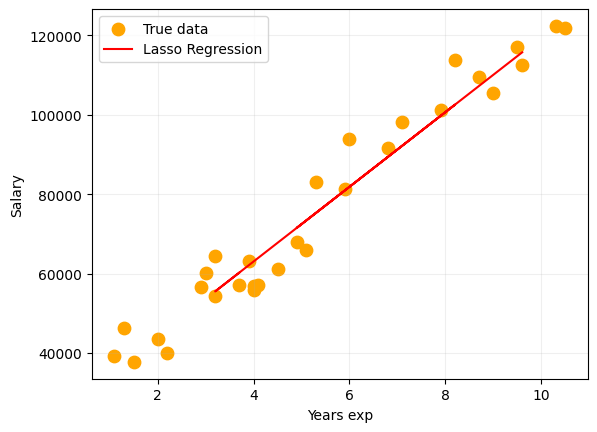

In [19]:
plt.scatter(x,y, color = 'Orange', s = 80, label = 'True data')
plt.plot(x_test, y_PRED, color = 'red', label = 'Lasso Regression')
plt.xlabel('Years exp')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha = 0.2)
plt.show()

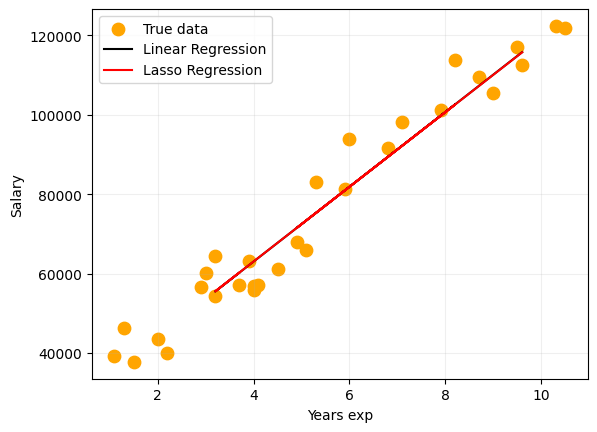

In [20]:
plt.scatter(x,y, color = 'Orange', s = 80, label = 'True data')
plt.plot(x_test, y_Pred, color = 'k', label = 'Linear Regression')
plt.plot(x_test, y_PRED, color = 'red', label = 'Lasso Regression')
plt.xlabel('Years exp')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha = 0.2)
plt.show()